In [2]:
#pip install -e ..

In [3]:
import numpy as np
from missing_methods import missingness_recommendations
rng = np.random.default_rng(0)
X = rng.standard_normal((10, 4))
Y = rng.standard_normal((10, 4)) + 0.3 * X
X[[1, 3, 7], 2] = np.nan
Y[[0, 4, 9], 1] = np.nan
missingness_recommendations(X, Y)

,method,condition,trigger,severity,message,action,neutral
0,PCA,low_row_coverage,False,ok,OK,,True
1,PCA,low_col_coverage,False,ok,OK,,True
2,PLS,low_row_coverage,False,ok,OK,,False
3,PLS,no_xy_overlap,False,ok,OK,,True
4,MFA,uneven_block_coverage,False,ok,OK,,True
5,RV,low_xy_overlap,False,ok,OK,,True
6,RV2,low_xy_overlap,False,ok,OK,,True


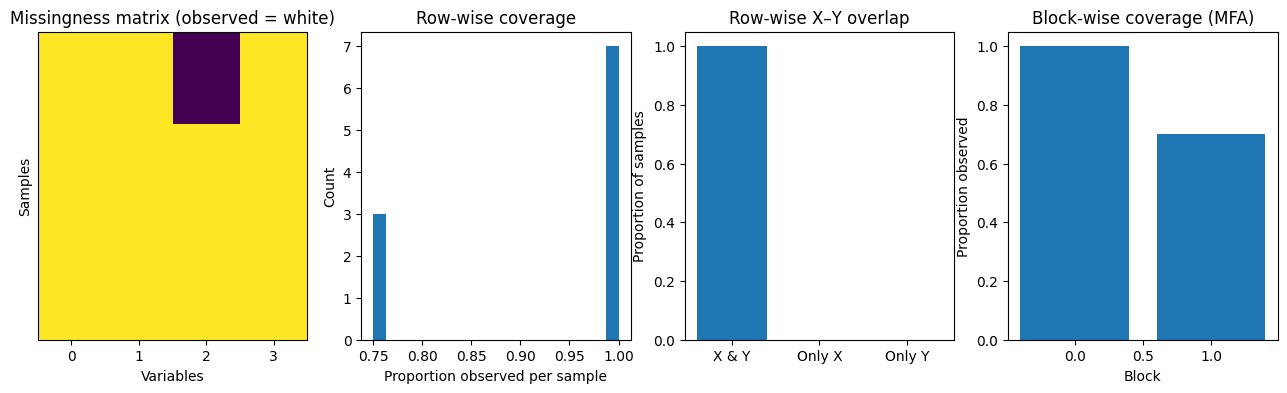

In [12]:
import matplotlib.pyplot as plt
plot_missingness_overview(X, Y, [[0,1],[2]])
#plot_block_coverage(X,[[0,1],[2]])

In [4]:
def plot_missing_matrix(X, sort_rows=True, ax=None):

    mask = ~np.isnan(X)

    if sort_rows:
        order = np.argsort(mask.mean(axis=1))
        mask = mask[order]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))

    ax.imshow(mask, aspect="auto", interpolation="nearest")
    ax.set_xlabel("Variables")
    ax.set_ylabel("Samples")
    ax.set_title("Missingness matrix (observed = white)")
    ax.set_yticks([])


def plot_row_coverage(X, ax=None):

    row_prop = (~np.isnan(X)).mean(axis=1)

    if ax is None:
        fig, ax = plt.subplots()

    ax.hist(row_prop, bins=20)
    ax.set_xlabel("Proportion observed per sample")
    ax.set_ylabel("Count")
    ax.set_title("Row-wise coverage")


def plot_xy_overlap(X, Y, ax=None):
    import matplotlib.pyplot as plt

    maskX = ~np.isnan(X)
    maskY = ~np.isnan(Y)

    both = (maskX.any(axis=1) & maskY.any(axis=1)).mean()
    onlyX = (maskX.any(axis=1) & ~maskY.any(axis=1)).mean()
    onlyY = (~maskX.any(axis=1) & maskY.any(axis=1)).mean()

    if ax is None:
        fig, ax = plt.subplots()

    ax.bar(["X & Y", "Only X", "Only Y"], [both, onlyX, onlyY])
    ax.set_ylabel("Proportion of samples")
    ax.set_title("Row-wise X–Y overlap")


def plot_block_coverage(X, blocks, ax=None):

    cov = []
    for cols in blocks:
        cov.append((~np.isnan(X[:, cols])).mean())

    if ax is None:
        fig, ax = plt.subplots()

    ax.bar(range(len(cov)), cov)
    ax.set_xlabel("Block")
    ax.set_ylabel("Proportion observed")
    ax.set_title("Block-wise coverage (MFA)")


def plot_missingness_overview(X, Y=None, blocks=None):

    nplots = 2 + (Y is not None) + (blocks is not None)
    fig, axes = plt.subplots(1, nplots, figsize=(4*nplots, 4))

    i = 0
    plot_missing_matrix(X, ax=axes[i]); i += 1
    plot_row_coverage(X, ax=axes[i]); i += 1

    if Y is not None:
        plot_xy_overlap(X, Y, ax=axes[i]); i += 1
    if blocks is not None:
        plot_block_coverage(X, blocks, ax=axes[i])



In [10]:
import missing_methods as mm
import numpy as np
import hoggorm as ho

In [11]:
X = np.array([[2.5, 2.4],
              [0.5, 0.7],
              [2.2, 2.9]])
Y = np.array([[2.4, 2.9],
              [0.6, 0.5],
              [2.1, 2.2]])

In [12]:
print(mm.rv(X, Y))
print(mm.rv_list([X, Y]))
print(ho.RVcoeff([X - np.mean(X, axis=0), Y - np.mean(Y, axis=0)]))
print(mm.rv2(X, Y))
print(mm.rv2_list([X, Y]))
print(ho.RV2coeff([X - np.mean(X, axis=0), Y - np.mean(Y, axis=0)]))

0.9209514798563275
[[1.         0.92095148]
 [0.92095148 1.        ]]
[[1.         0.92095148]
 [0.92095148 1.        ]]
0.8934727185169297
[[1.         0.89347272]
 [0.89347272 1.        ]]
[[1.         0.89347272]
 [0.89347272 1.        ]]


In [13]:
mm.pls(X, Y, ncomp=2)

{'scores': array([[ 0.82945384,  0.28751703],
        [-1.79021053, -0.0137231 ],
        [ 0.96075669, -0.27379393]]),
 'weights': array([[ 0.71961413,  0.69437419],
        [ 0.69437419, -0.71961413]]),
 'loadings_x': array([[ 0.68360919,  0.69437419],
        [ 0.73168788, -0.71961413]]),
 'loadings_y': array([[0.60926336, 0.67698308],
        [0.75250212, 1.42310723]]),
 'explained': array([4.81590083, 0.15781748]),
 'means_x': array([1.73333333, 2.        ]),
 'means_y': array([1.7       , 1.86666667]),
 'residual_x': array([[ 2.77555756e-17,  2.77555756e-17],
        [-3.81639165e-17, -3.81639165e-17],
        [ 2.77555756e-17,  0.00000000e+00]]),
 'residual_y': array([[-2.77555756e-17,  1.11022302e-16],
        [ 4.68375339e-17,  3.57353036e-16],
        [ 0.00000000e+00,  2.22044605e-16]])}

In [14]:
rng = np.random.default_rng(2026)
X = rng.standard_normal((120, 20))
Y = rng.standard_normal((120, 20)) + X
Z = rng.standard_normal((120, 20)) + X
Xnan = X.copy()
Ynan = Y.copy()
Znan = Z.copy()
Xnan[[0, 4, 7], 2] = np.nan
Ynan[[1, 3, 9], 4] = np.nan
Znan[[2, 5, 8], 6] = np.nan
print("RV without missing data:", mm.rv(X, Y))
print("RV with missing data:", mm.rv(Xnan, Ynan))
print("RV list without missing data:", mm.rv_list([X, Y, Z]))
print("RV list with missing data:", mm.rv_list([Xnan, Ynan, Znan]))
ho.RVcoeff([X - np.mean(X, axis=0), Y - np.mean(Y, axis=0), Z - np.mean(Z, axis=0)])

RV without missing data: 0.559365400476794
RV with missing data: 0.5555852877340515
RV list without missing data: [[1.         0.5593654  0.56180147]
 [0.5593654  1.         0.34775426]
 [0.56180147 0.34775426 1.        ]]
RV list with missing data: [[1.         0.55558529 0.55858512]
 [0.55558529 1.         0.34458374]
 [0.55858512 0.34458374 1.        ]]


array([[1.        , 0.55936541, 0.56180148],
       [0.55936541, 1.        , 0.34775423],
       [0.56180148, 0.34775423, 1.        ]])

In [15]:
# Example with mm.pca
out1 = mm.pca(Xnan, ncomp=5)

# Hoggorm example
hopca = ho.nipalsPCA(X, numComp=5)

In [16]:
out1["scores"][:5, :5]

array([[-0.3353226 ,  0.84149302, -0.60059606,  0.48284849, -0.6201295 ],
       [-1.83066533, -0.63763463, -0.02721384,  0.98320384, -1.07572918],
       [ 2.30050297,  1.48638404, -0.04543463, -0.97782057,  1.0420846 ],
       [-2.22960421, -1.53458927,  2.5189156 , -0.86208389, -0.07855361],
       [ 0.41014659,  3.01211792,  1.53837116, -0.74024656,  0.63143473]])

In [17]:
hopca.X_scores()[:5, :5]

array([[-0.05661093,  0.73779957,  0.36182842, -0.22318321, -0.76213281],
       [-1.83450677, -0.61571983,  0.02330123,  0.85685066, -1.23186402],
       [ 2.31045785,  1.4936774 , -0.07617076, -0.95756508,  1.11150737],
       [-2.28504626, -1.43540251,  2.45486629, -0.97222205,  0.16098958],
       [ 0.36549845,  2.88370128,  1.29471403, -0.42134402,  0.81379832]])

In [18]:
# Example with mm.mfa
mfa_blocks = [Xnan[:, :10], Ynan[:, :10], Znan[:, :10]]
out_mfa = mm.mfa(mfa_blocks, ncomp=3)
print("Explained variance:", np.round(out_mfa["explained_variance"][:3], 3))
print("Block corrload shapes:", [b.shape for b in out_mfa["block_correlation_loadings"]])
out_mfa["scores"][:3, :3]

Explained variance: [0.12  0.109 0.1  ]
Block corrload shapes: [(10, 3), (10, 3), (10, 3)]


array([[-0.03789316, -0.03097783,  0.13343976],
       [-0.11471879,  0.09512049, -0.05830158],
       [ 0.17187609, -0.18943872, -0.06705073]])

In [19]:
out_mfa

{'scores': array([[-3.78931603e-02, -3.09778300e-02,  1.33439760e-01],
        [-1.14718790e-01,  9.51204906e-02, -5.83015773e-02],
        [ 1.71876090e-01, -1.89438722e-01, -6.70507269e-02],
        [-2.13488206e-01, -2.33275391e-02,  8.80476269e-02],
        [ 6.60259969e-02, -2.70671208e-03,  9.29684739e-02],
        [-1.92818811e-01, -1.23865347e-01, -1.55273805e-01],
        [-7.22749674e-02,  5.34724143e-02,  7.56314307e-02],
        [-9.05572776e-06,  1.51476671e-02,  2.87396770e-02],
        [ 1.23516463e-01,  3.16643019e-01, -2.04689751e-01],
        [-5.43251143e-02,  4.28509844e-01, -9.25506224e-02],
        [-7.59250153e-02, -6.48578659e-02, -9.05814656e-02],
        [-1.58895364e-01, -6.65538392e-03,  9.25375926e-03],
        [ 1.89937125e-01,  9.47707907e-02, -9.99767514e-02],
        [-1.15316840e-02, -2.34736743e-01,  1.72148276e-01],
        [ 1.03391075e-01,  1.38658746e-01, -7.76844990e-02],
        [-1.28994144e-02,  2.98161149e-03, -1.27085624e-01],
        [-8.38

In [20]:
print(mm.normalize(Xnan))
print(mm.standardize(Xnan)) 

[[-0.06197069  0.02220627         nan ...  0.05510338 -0.01342836
  -0.12610917]
 [-0.03729221  0.06061037 -0.02068839 ... -0.04596992  0.05212919
   0.08044244]
 [ 0.01597239 -0.05796722 -0.07355181 ...  0.02852658  0.1325598
  -0.05097709]
 ...
 [ 0.13424084  0.08029091 -0.01989589 ... -0.0594988  -0.225686
  -0.10919528]
 [-0.02656747  0.06315244  0.01542088 ... -0.03279322 -0.09371536
  -0.13632455]
 [ 0.0221706  -0.12191602 -0.01333572 ... -0.07262405  0.11405017
  -0.04527993]]
[[-0.83224111  0.31547118         nan ...  0.66392837 -0.07991677
  -1.30200918]
 [-0.56004494  0.73552195 -0.14194336 ... -0.4407634   0.63684369
   0.95808303]
 [ 0.02744755 -0.56143864 -0.71325942 ...  0.37345435  1.51621568
  -0.47991232]
 ...
 [ 1.33191275  0.95078089 -0.13337843 ... -0.58862874 -2.40059333
  -1.11693699]
 [-0.44175424  0.76332624  0.24830402 ... -0.29674724 -0.95771873
  -1.41378608]
 [ 0.09581195 -1.26088844 -0.06248004 ... -0.7320827   1.31384434
  -0.41757393]]
